# Basic Agentic Workflow

Helloooo everyone and welcome to an exciting lesson on Agentic AI! 🎉

Today, we're diving into **prompt chaining** agentic workflow pattern. What's that? It's just passing the output from one LLM to the next, step by step. Think of it like a relay race, but with prompts instead of batons.

We'll keep things super simple: manually run each cell, watch the magic happen, and see how chaining LLM calls lets us build more complex workflows.

Ready to see how agents can work together? Let's get started!

## As always, libraries first!

If the following error occurs, PIP needs to be installed.

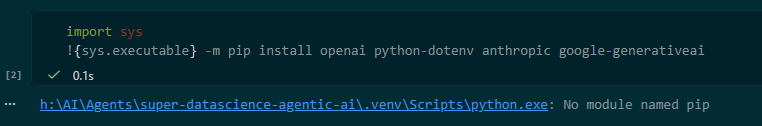

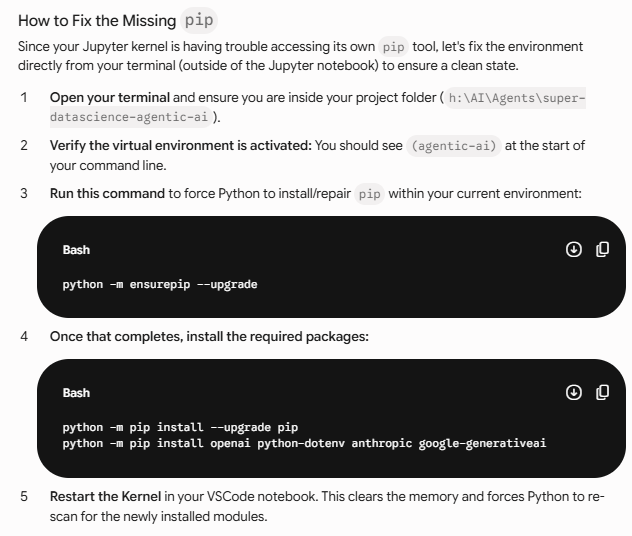

In [1]:
import sys
!{sys.executable} -m pip install openai python-dotenv anthropic google.genai
!{sys.executable} -m pip install -U google-genai
!{sys.executable} -m pip install -U google-generativeai

In [2]:
from config import Config # for configuration management

import os # for environment variable management
from openai import OpenAI # for interacting with OpenAI's API
from dotenv import load_dotenv # for managing environment variables
from IPython.display import display, Markdown # for displaying output
from anthropic import Anthropic # for interacting with Anthropic's API
import google.genai as genai # for interacting with Google's Generative AI API
from google.genai import types # for interacting with Google's Generative AI API
# import google.generativeai as genai # for interacting with Google's Generative AI API

In [3]:
google_client = genai.Client(api_key=Config.GEMINI_API_KEY)
anthropic_client = Anthropic(api_key=Config.ANTHROPIC_API_KEY)
openai_client = OpenAI(api_key=Config.OPENAI_API_KEY)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [4]:
# load_dotenv()

# OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
# GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
# ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")

# # check if API keys are set
# if not OPENAI_API_KEY:
#     raise ValueError("Missing OpenAI API key")
# if not GEMINI_API_KEY:
#     raise ValueError("Missing Gemini API key")
# if not ANTHROPIC_API_KEY:
#     raise ValueError("Missing Anthropic API key")

You can set your API Keys for each of the LLM providers using the following links:

- [OpenAI](https://platform.openai.com/api-keys)
- [Anthropic](https://console.anthropic.com/settings/keys)
- [Gemini](https://aistudio.google.com/app/apikey)

Once you have created the API Keys, you can store them on your `.env` file at the root of this repo

<div style="border-radius:16px;background:#2e3440;margin:1em 0;padding:1em 1em 1em 3em;color:#eceff4;position:relative;box-shadow:0 6px 16px rgba(0,0,0,.4)">
    <b style="color:#88c0d0;font-size:1.25em">Info:</b>
    <ul style="margin:.6em 0 0;padding-left:1.2em;line-height:1.6">
        <li>You can complete this entire notebook using just OpenAI models if you prefer!</li>
        <li>It's absolutely fine to skip Anthropic and Gemini for now — the workflow works perfectly with only OpenAI.</li>
        <li>Feel free to experiment with other providers later, but don't let missing API keys slow you down.</li>
    </ul>
    <div style="position:absolute;top:-.8em;left:-.8em;width:2.4em;height:2.4em;border-radius:50%;background:#88c0d0;color:#2e3440;display:flex;align-items:center;justify-content:center;font-weight:700;font-size:1.2em">💡</div>
</div>

## The Workflow

```mermaid
graph LR
    A[Generate Tickets] --> B[Classify Priority] --> C[Respond to Tickets]
```

## Lets start with using OpenAI

In [5]:
# messages list
message = "I want you to generate a customer support ticket for a 3rd party re-seller. "
message += "The ticket should be a single sentence describing a common issue a customer might face with their product or service. "
message += "Please ensure the ticket is varied and covers different types of problems. "
message += "Do not give any subjects, only the body of the ticket."

messages = [{"role": "user", "content": message}]

In [6]:
# response

openai_response = openai_client.chat.completions.create(
    model=Config.DEFAULT_OPENAI_MODEL,
    messages=messages
)

ticket = openai_response.choices[0].message.content
# print(f"### Generated Ticket:\n{ticket}")
display(Markdown(f"### Generated Ticket:\n{ticket}"))

### Generated Ticket:
The product I purchased from your reseller isn’t powering on despite multiple attempts.

I love markdown. It is a lightweight method of rendering and formatting text that is super versatile without having to use heavy softwares like MS Word or Google Docs.

You can learn more about markdown syntax [here](https://www.markdownguide.org/basic-syntax/)

A really informative YouTube video talking about the [Unreasonable Effectiveness of Plain Text](https://www.youtube.com/watch?v=WgV6M1LyfNY)

## Lets pass these on to an Anthropic model and ask it to classify the priority level of each ticket

You might get an error trying to execute Anthropic's model using OpenAI.

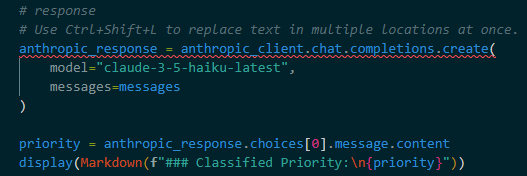
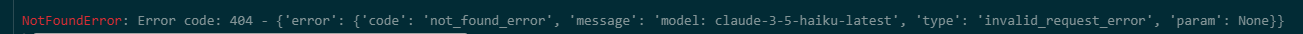
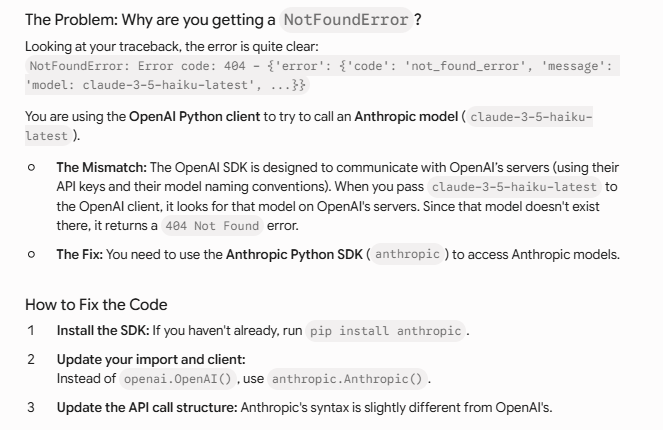

To fix this, install Anthropic and then execute the following code:

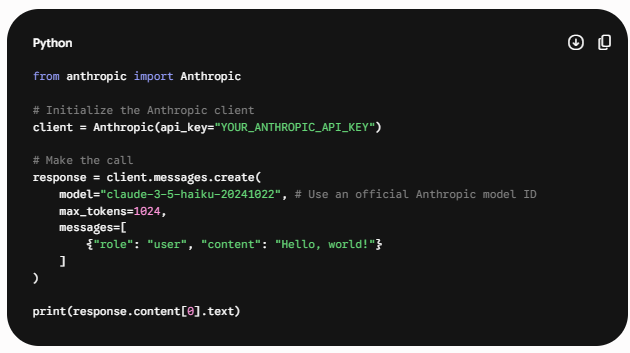

In [7]:
# anthropic client, pass in base_url
# The OpenAI class is a simple python wrapper for the OpenAI API. It can be used to interact with the API in a more convenient way. 
# The base_url parameter allows you to specify the base URL for the API, which is useful if you want to use a different endpoint (e.g., for Anthropic's API).

# anthropic_client = OpenAI(api_key=ANTHROPIC_API_KEY, base_url="https://api.anthropic.com/v1") --> Does not work

# anthropic_client = Anthropic(api_key=ANTHROPIC_API_KEY)


In [8]:
# messages list
message = "I want you to classify the priority of the following customer support ticket. "
message += "The ticket is as follows: "+ ticket + " "
message += "Please classify the priority as either 'Low', 'Medium', or 'High'. "
message += "Respond with only the priority level."

messages = [{"role": "user", "content": message}]

In [9]:
# response
# Use Ctrl+Shift+L to replace text in multiple locations at once.
anthropic_response = anthropic_client.messages.create(
    model=Config.DEFAULT_ANTHROPIC_MODEL, 
    messages = messages,
    max_tokens=Config.DEFAULT_MAX_TOKENS
)

priority = anthropic_response.content[0].text.strip()
display(Markdown(f"### Classified Priority:\n{priority}"))

### Classified Priority:
High

## Now Gemini should determine the appropriate response

In [10]:
# gemini client
# gemini_client = OpenAI(api_key=GEMINI_API_KEY, base_url="https://generativelanguage.googleapis.com/v1beta/openai/")

In [11]:
# messages list

message = "You are to determine an appropriate response to the following customer support ticket. "
message += "The ticket is as follows: "+ ticket + " "
message += "The priority level of this ticket is: " + priority + " "
message += "Please provide a response that addresses the customer's issue in a short and concise manner. "
    
messages = [{"role": "user", "content": message}]

In [12]:
# 1. Structure your content properly using the SDK types
formatted_contents = [
    types.Content(
        role="user",
        parts=[types.Part.from_text(text=message)]
    )
]

# 2. Use the formatted contents in your call
gemini_response = google_client.models.generate_content(
    model=Config.DEFAULT_GEMINI_MODEL,
    contents=formatted_contents, # Use the correctly structured list
    config={"max_output_tokens": Config.DEFAULT_MAX_TOKENS}
)

response_text = gemini_response.text
print(response_text)

Subject: Assistance with your [Product Name]

Dear Customer,

I am sorry to hear that your device is not powering on. Given the urgency, I would like to help resolve this immediately.

To better assist you, could you please provide the following details?
1. The serial number of the unit.
2. A copy or photo of your purchase receipt from the reseller. 

Once received, I will prioritize this case and provide you with troubleshooting steps or return instructions.

Best regards,

[Your Name]
Customer Support Team


<div style="border-radius:16px;background:#1e2a1e;margin:1em 0;padding:1em 1em 1em 3em;color:#eceff4;position:relative;box-shadow:0 6px 16px rgba(0,0,0,.4)">
    <b style="color:#a3be8c;font-size:1.25em">Your Challenge:</b>
    <ul style="margin:.6em 0 0;padding-left:1.2em;line-height:1.6"></ul>
        <li>Recreate the customer support ticket workflow using an <b>evaluator-optimizer agentic workflow pattern</b> instead of prompt chaining.</li>
        <li>Your evaluator agent should assess the quality and completeness of each ticket and suggest improvements.</li>
        <li>Your optimizer agent should revise the tickets based on evaluator feedback, aiming for clarity and actionable details.</li>
        <li>Try to implement this using at least two LLM calls (one for evaluation, one for optimization) and display the before/after results.</li>
        <li>Share your work in the community-contributions folder by creating a folder with your name. Eg. shaheer-airaj.</li>
    </ul>
    <div style="position:absolute;top:-.8em;left:-.8em;width:2.4em;height:2.4em;border-radius:50%;background:#a3be8c;color:#2e3440;display:flex;align-items:center;justify-content:center;font-weight:700;font-size:1.2em">💪</div>
</div>